In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel('/content/hospital.xlsx')

df

,ID,NOME,IDADE,SEXO,PESO,MANCHAS,TEMP.,#INT.,EST.,DIAGNÓSTICO
0,4201,João,28,M,79,Concentradas,38.0,2,SP,Doente
1,3217,Maria,18,F,67,Inexistentes,39.5,4,MG,Doente
2,4039,Luiz,49,M,92,Espalhadas,38.0,2,RS,Saudável
3,1920,José,18,M,43,Inexistentes,38.5,8,MG,Doente
4,4340,Cláudia,21,F,52,Uniformes,37.6,1,PE,Saudável
5,2301,Ana,22,F,72,Inexistentes,38.0,3,RJ,Doente
6,1322,Marta,19,F,87,Espalhadas,39.0,6,AM,Doente
7,3027,Paulo,34,M,67,Uniformes,38.4,2,GO,Saudável


# 1. Estatísticas univariadas

In [7]:
colunas_categoricas = [
    'SEXO',
    'MANCHAS',
    'EST.',
    'DIAGNÓSTICO'
]

colunas_quantitativas = [
    'IDADE',
    'PESO',
    'TEMP.',
    '#INT.'
]

### Frequência e Moda

In [8]:
for coluna in colunas_categoricas:
    print('=' * 50)
    print(f'Coluna: {coluna}')

    print('\nFrequências:')
    print(df[coluna].value_counts())

    print('\nModa:')
    print(df[coluna].mode().tolist())

Coluna: SEXO

Frequências:
SEXO
M    4
F    4
Name: count, dtype: int64

Moda:
['F', 'M']
Coluna: MANCHAS

Frequências:
MANCHAS
Inexistentes    3
Espalhadas      2
Uniformes       2
Concentradas    1
Name: count, dtype: int64

Moda:
['Inexistentes']
Coluna: EST.

Frequências:
EST.
MG    2
SP    1
RS    1
PE    1
RJ    1
AM    1
GO    1
Name: count, dtype: int64

Moda:
['MG']
Coluna: DIAGNÓSTICO

Frequências:
DIAGNÓSTICO
Doente      5
Saudável    3
Name: count, dtype: int64

Moda:
['Doente']


### Estatísticas das variáveis quantitativas

In [9]:
estatisticas = pd.DataFrame({
    'Média': df[colunas_quantitativas].mean(),
    'Mediana': df[colunas_quantitativas].median(),
    'Desvio-padrão': df[colunas_quantitativas].std(),
    'Q1': df[colunas_quantitativas].quantile(0.25),
    'Q3': df[colunas_quantitativas].quantile(0.75),
    'Obliquidade': df[colunas_quantitativas].skew(),
    'Curtose': df[colunas_quantitativas].kurt()
})

estatisticas

,Média,Mediana,Desvio-padrão,Q1,Q3,Obliquidade,Curtose
IDADE,26.125,21.5,10.789380,18.75,29.500,1.641706,2.435543
PESO,69.875,69.5,16.599806,63.25,81.000,-0.355942,-0.581069
TEMP.,38.375,38.2,0.620484,38.00,38.625,0.834229,0.130304
#INT.,3.500,2.5,2.390457,2.00,4.500,1.129491,0.386750


# 2. Covariância e correlação

### Matriz de covariância

In [10]:
covariancia = df[colunas_quantitativas].cov()

covariancia

,IDADE,PESO,TEMP.,#INT.
IDADE,116.410714,100.446429,-2.596429,-13.214286
PESO,100.446429,275.553571,0.767857,-11.214286
TEMP.,-2.596429,0.767857,0.385000,0.842857
#INT.,-13.214286,-11.214286,0.842857,5.714286


### Matriz de correlação

In [11]:
correlacao = df[colunas_quantitativas].corr()

correlacao

,IDADE,PESO,TEMP.,#INT.
IDADE,1.000000,0.560835,-0.387837,-0.512349
PESO,0.560835,1.000000,0.074550,-0.282610
TEMP.,-0.387837,0.074550,1.000000,0.568254
#INT.,-0.512349,-0.282610,0.568254,1.000000


# 3. Boxplots

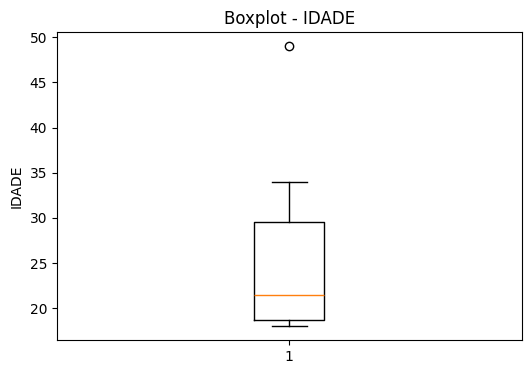

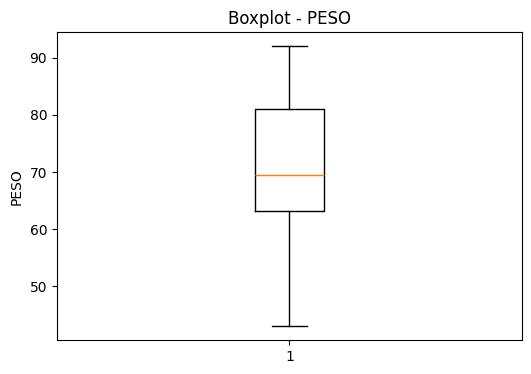

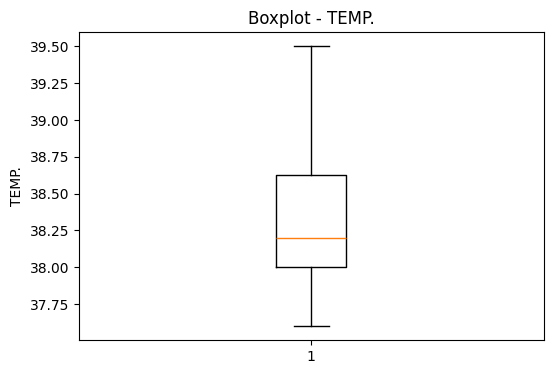

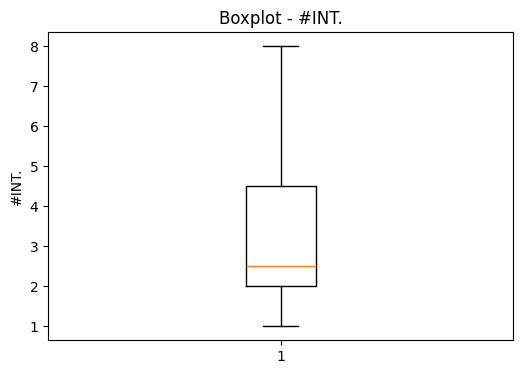

In [12]:
for coluna in colunas_quantitativas:

    plt.figure(figsize=(6, 4))

    plt.boxplot(df[coluna])

    plt.title(f'Boxplot - {coluna}')
    plt.ylabel(coluna)

    plt.show()

### Identificar os outliers

In [13]:
for coluna in colunas_quantitativas:

    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[
        (df[coluna] < limite_inferior) |
        (df[coluna] > limite_superior)
    ]

    print("=" * 50)
    print(f"Coluna: {coluna}")

    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"Limite inferior: {limite_inferior}")
    print(f"Limite superior: {limite_superior}")

    if len(outliers) == 0:
        print("Não possui outliers.")
    else:
        print("Outliers encontrados:")
        print(outliers[[coluna]])

Coluna: IDADE
Q1: 18.75
Q3: 29.5
Limite inferior: 2.625
Limite superior: 45.625
Outliers encontrados:
   IDADE
2     49
Coluna: PESO
Q1: 63.25
Q3: 81.0
Limite inferior: 36.625
Limite superior: 107.625
Não possui outliers.
Coluna: TEMP.
Q1: 38.0
Q3: 38.625
Limite inferior: 37.0625
Limite superior: 39.5625
Não possui outliers.
Coluna: #INT.
Q1: 2.0
Q3: 4.5
Limite inferior: -1.75
Limite superior: 8.25
Não possui outliers.


# 4. Histogramas considerando as classes

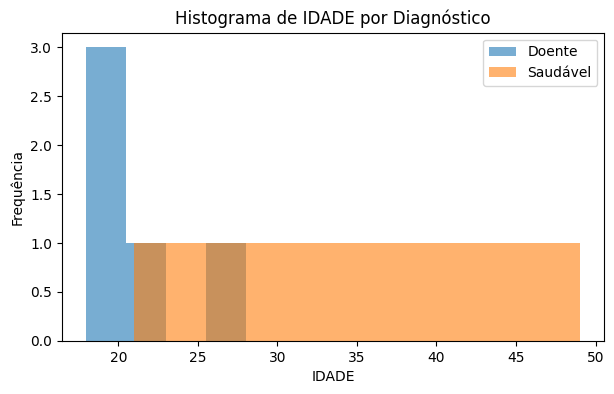

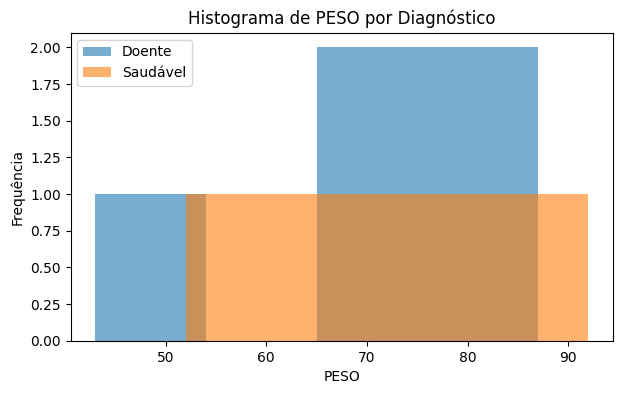

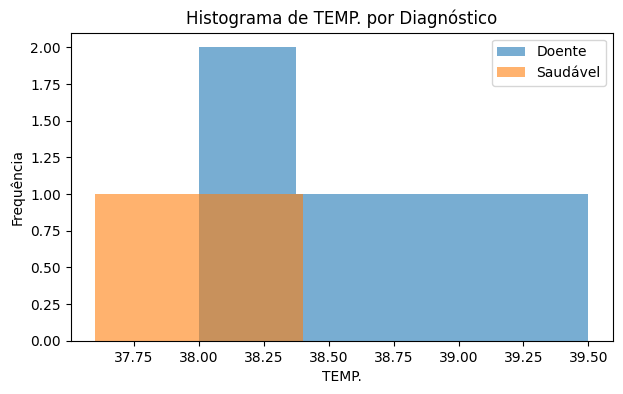

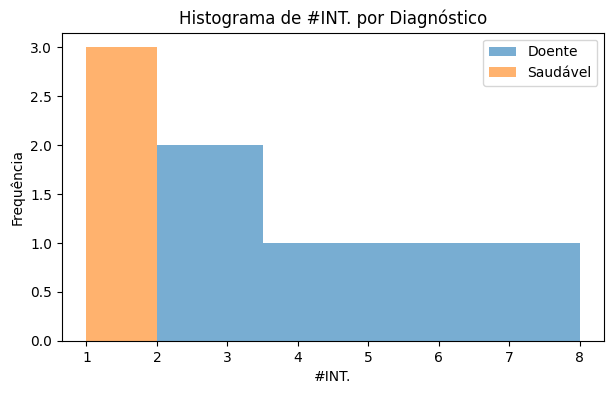

In [14]:
classes = df['DIAGNÓSTICO'].unique()

for coluna in colunas_quantitativas:

    plt.figure(figsize=(7, 4))

    for classe in classes:

        dados = df[df['DIAGNÓSTICO'] == classe][coluna]

        plt.hist(
            dados,
            bins='auto',
            alpha=0.6,
            label=classe
        )

    plt.title(f'Histograma de {coluna} por Diagnóstico')

    plt.xlabel(coluna)
    plt.ylabel('Frequência')

    plt.legend()

    plt.show()